In [182]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df = pd.read_csv(r"C:\Users\New folder\quick_commerce.csv")

In [3]:
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.33750,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.30000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.66000,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8
3,1000004,Swiggy Instamart,Delhi,23,1179.05925,5.864,6.44,2.0,Dairy,Credit Card,5.0,1,5.0
4,1000005,Dunzo,Mumbai,44,586.02550,12.470,2.45,13.0,Household,Wallet,3.7,0,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33000,17.806,3.01,19.0,Fruits & Vegetables,Wallet,4.2,0,2.8
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66300,18.306,10.51,9.0,Beverages,Debit Card,4.1,1,3.5
999997,1999998,Jio Mart,Noida,29,637.32300,17.590,2.65,6.0,Groceries,Cash on Delivery,3.4,0,4.6
999998,1999999,Dunzo,Pune,42,1103.12100,12.656,7.76,12.0,Snacks,Wallet,4.0,1,4.5


In [4]:
df.columns = df.columns.str.strip()

In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.options.display.float_format = "{:,.2f}".format

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [7]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,"1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","1,000,000.00","965,000.00","953,000.00","1,000,000.00","895,863.00"
mean,"1,500,000.50",38.47,571.64,16.45,7.75,10.00,3.04,0.40,3.75
std,"288,675.28",12.12,382.78,6.26,4.19,5.48,1.19,0.49,0.72
min,"1,000,001.00",18.00,50.00,5.00,0.50,1.00,1.00,0.00,2.50
25%,"1,250,000.75",28.00,287.84,12.37,4.13,5.00,2.00,0.00,3.10
50%,"1,500,000.50",38.00,531.32,16.34,7.74,10.00,3.00,0.00,3.70
75%,"1,750,000.25",49.00,796.18,20.20,11.38,15.00,4.00,1.00,4.40
max,"2,000,000.00",59.00,"13,877.33",40.00,15.00,19.00,5.00,1.00,5.00


In [8]:
# Missing Values
df.isna().sum()

Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

In [9]:
# To get data where we have atleast one missing values
df[df.isna().any(axis=1)]

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
2,1000003,Flipkart Minutes,Mumbai,18,"1,211.66",16.91,4.85,NaN,Personal Care,Cash on Delivery,3.30,0,3.80
6,1000007,Blinkit,Bengluru,37,516.86,18.48,12.46,19.00,Snacks,Debit Card,2.80,0,NaN
17,1000018,Zepto,Delhi,23,"1,041.43",5.00,14.74,18.00,Snacks,Wallet,NaN,1,NaN
21,1000022,Blinkit,NaN,41,716.90,17.80,11.34,7.00,Beverages,Credit Card,2.70,1,3.60
22,1000023,Jio Mart,Delhi,48,50.00,8.50,0.83,3.00,Snacks,Cash on Delivery,3.10,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999966,1999967,Dunzo,NaN,39,783.89,18.82,14.70,NaN,Household,Wallet,3.10,1,4.90
999975,1999976,Amazon Now,Bengluru,34,515.89,21.29,10.49,10.00,Fruits & Vegetables,Wallet,NaN,1,3.00
999981,1999982,Amazon Now,NaN,33,939.34,21.08,11.80,18.00,Dairy,Wallet,3.20,1,4.40
999983,1999984,Swiggy Instamart,Hyderabad,42,50.00,13.39,2.31,2.00,Groceries,Wallet,NaN,0,3.20


In [10]:
# Removing rows with Null Values

df = df.dropna(subset = ["City"])
df.shape

(948000, 13)

In [11]:
# Filling missing values with Mode
x = df["Items_Count"].mode()
df["Items_Count"].fillna(x[0])

0        12.00
1        10.00
2        19.00
3         2.00
4        13.00
          ... 
999995   19.00
999996    9.00
999997    6.00
999998   12.00
999999   13.00
Name: Items_Count, Length: 948000, dtype: float64

In [30]:
df["Items_Count"] = df["Items_Count"].fillna(df["Items_Count"].mode()[0])

In [13]:
# Group on Company to find Mean/Median and fill customer rating
df.groupby("Company")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))

0        2.10
1        2.30
2        3.30
3        5.00
4        3.70
         ... 
999995   4.20
999996   4.10
999997   3.40
999998   4.00
999999   4.10
Name: Customer_Rating, Length: 948000, dtype: float64

In [31]:
# OR
df.loc[:, "Customer_Rating"] = df["Customer_Rating"].fillna(
    df.groupby("Company")["Customer_Rating"].transform("mean")
)

In [32]:
# # Group on Company to find Mean/Median and fill Delivery Partner rating

df.loc[:,"Delivery_Partner_Rating"] = df["Delivery_Partner_Rating"].fillna(
    df.groupby("Delivery_Time_Min")["Delivery_Partner_Rating"].transform("mean")
)

In [33]:
df.loc[:,"Delivery_Partner_Rating"] = df["Delivery_Partner_Rating"].fillna(
    df["Delivery_Partner_Rating"].mean()
)

In [17]:
df = df[df["Order_Value"] <= 2500]
df

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.34,19.18,11.97,12.00,Dairy,Wallet,2.10,1,3.20
1,1000002,Flipkart Minutes,Amritsar,56,"1,007.30",19.64,12.74,10.00,Snacks,Cash on Delivery,2.30,0,3.20
2,1000003,Flipkart Minutes,Mumbai,18,"1,211.66",16.91,4.85,19.00,Personal Care,Cash on Delivery,3.30,0,3.80
3,1000004,Swiggy Instamart,Delhi,23,"1,179.06",5.86,6.44,2.00,Dairy,Credit Card,5.00,1,5.00
4,1000005,Dunzo,Mumbai,44,586.03,12.47,2.45,13.00,Household,Wallet,3.70,0,4.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1999996,Big Basket,Mumbai,48,72.33,17.81,3.01,19.00,Fruits & Vegetables,Wallet,4.20,0,2.80
999996,1999997,Swiggy Instamart,Mumbai,33,"1,509.66",18.31,10.51,9.00,Beverages,Debit Card,4.10,1,3.50
999997,1999998,Jio Mart,Noida,29,637.32,17.59,2.65,6.00,Groceries,Cash on Delivery,3.40,0,4.60
999998,1999999,Dunzo,Pune,42,"1,103.12",12.66,7.76,12.00,Snacks,Wallet,4.00,1,4.50


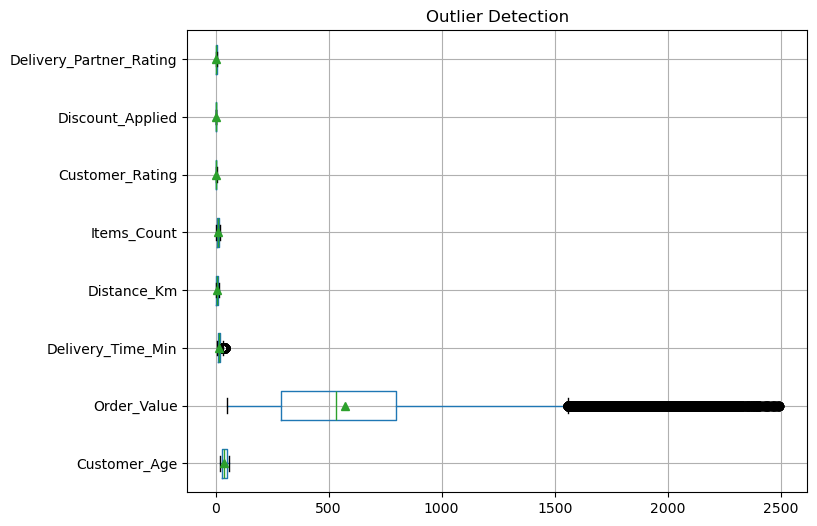

In [18]:
fig, ax = plt.subplots(figsize=(8,6))

df.drop(columns=["Order_ID"]).boxplot(
    vert=False,
    showmeans=True,
    ax=ax
)

ax.set_title("Outlier Detection")
plt.show()

## **Change Column Data Types**

In [19]:
df["Order_ID"] = df["Order_ID"].astype(str)

In [20]:
df['Order_Value'] = df['Order_Value'].round().astype(int)
df['Delivery_Time_Min'] = df['Delivery_Time_Min'].round().astype(int)
df['Distance_Km'] = df['Distance_Km'].round(1)
df['Customer_Rating'] = df['Customer_Rating'].round(1)
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].round(1)

### **Which quick commerce platform has the highest total revenue?**

In [21]:
companies_Revenue = df.groupby("Company")["Order_Value"].sum().sort_values(ascending = False)

In [22]:
df.groupby("Company")["Order_Value"].sum().nlargest(1)

Company
Swiggy Instamart    76407756
Name: Order_Value, dtype: int64

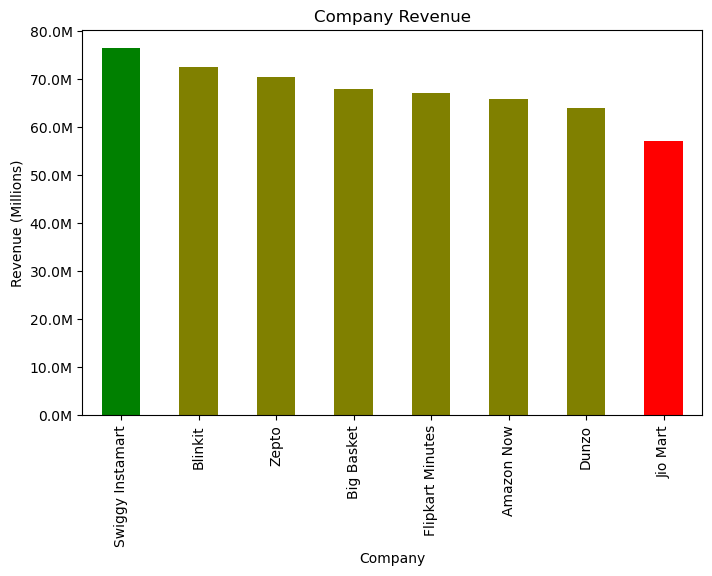

In [23]:
max_val = companies_Revenue.max()
min_val = companies_Revenue.min()

colors = ["green" if val == max_val else
          "red" if val == min_val else
          "olive"
          for val in companies_Revenue
         ]

companies_Revenue.plot(kind="bar", figsize=(8,5), color = colors)
def millions(x, pos):
    return f'{x/1e6:.1f}M'

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.title("Company Revenue")
plt.ylabel("Revenue (Millions)")
plt.show()

### **Which platforms has the highest avaerage order value?**

In [24]:
AOV = df.groupby("Company")["Order_Value"].mean().sort_values(ascending = False)

In [25]:
df.groupby("Company")["Order_Value"].mean().nlargest(1)

Company
Swiggy Instamart   644.93
Name: Order_Value, dtype: float64

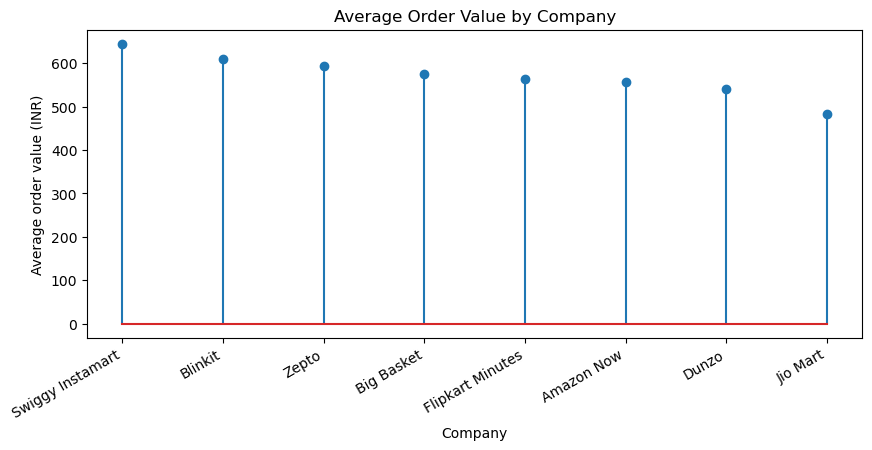

In [26]:
plt.figure(figsize = (10,4))
plt.stem(AOV.index, AOV.values)
plt.xlabel("Company")
plt.ylabel("Average order value (INR)")
plt.title("Average Order Value by Company")
plt.xticks(rotation = 30, ha="right")
plt.show()

### **How does customer ratings vary across the platforms?**

In [27]:
df.groupby("Company")["Customer_Rating"].mean().sort_values(ascending = False)

Company
Blinkit            3.56
Swiggy Instamart   3.28
Zepto              3.20
Big Basket         3.10
Flipkart Minutes   3.01
Amazon Now         2.91
Jio Mart           2.82
Dunzo              2.46
Name: Customer_Rating, dtype: float64

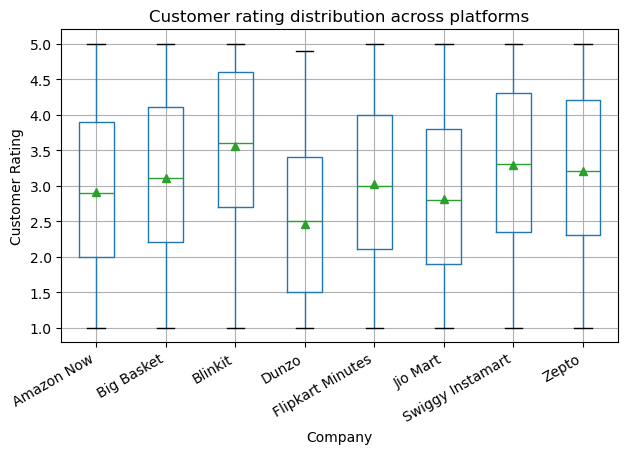

In [35]:
df.boxplot(column = "Customer_Rating", by="Company", showmeans=True)
plt.suptitle("")
plt.title("Customer rating distribution across platforms")
plt.ylabel("Customer Rating")
plt.xticks(rotation = 30, ha= "right")
plt.tight_layout()
plt.show()

In [37]:
df.groupby(["Company", "Customer_Rating"]).size().unstack(fill_value=0)  #Unstack reshape groupby result

Customer_Rating,1.00,1.10,1.20,1.30,1.40,1.50,1.60,1.70,1.80,1.90,2.00,2.10,2.20,2.30,2.40,2.50,2.60,2.70,2.80,2.90,3.00,3.10,3.20,3.30,3.40,3.50,3.60,3.70,3.80,3.90,4.00,4.10,4.20,4.30,4.40,4.50,4.60,4.70,4.80,4.90,5.00
Company,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Amazon Now,4896,2596,2628,2626,2747,2785,2937,2818,2717,2719,2854,2928,2860,2773,2735,2709,2807,2751,2777,8352,2807,2801,2924,2802,2845,2891,2810,2921,2716,2826,2729,2835,2825,2639,2492,2468,2652,2607,2465,1511,1502
Big Basket,1404,1274,2266,2527,2672,2619,2671,2749,2799,2770,2805,2863,2853,2855,2864,2712,2769,2799,2768,2840,2739,8425,2812,2861,2786,2841,2815,2844,2848,2747,2788,2926,2743,2876,2766,2714,2508,2557,2559,2449,5564
Blinkit,126,232,235,233,234,348,1239,2211,2529,2563,2550,2735,2885,2853,2865,2775,2787,2852,2884,2829,2920,2876,2744,2812,2857,2757,8368,2820,2824,2909,2831,2891,2737,2905,2798,2868,2872,2850,2759,2813,18711
Dunzo,18257,2871,2782,2873,2809,2777,2864,2782,2768,2862,2760,2888,2743,2921,2770,8371,2774,2825,2854,2875,2781,2864,2738,2869,2797,2792,2828,2874,2705,2530,2532,2552,2688,2485,1508,540,352,255,223,124,0
Flipkart Minutes,2665,2271,2405,2625,2583,2712,2738,2746,2764,2816,2786,2830,2852,2868,2856,2818,2895,2824,2884,2926,8412,2895,2822,2757,2810,2925,2766,2901,2855,2807,2946,2803,2800,2799,2730,2653,2606,2644,2584,2498,3088
Jio Mart,7549,2548,2619,2774,2795,2790,2781,2698,2862,2757,2830,2795,2776,2859,2777,2818,2788,2815,8570,2859,2741,2791,2856,2792,2871,2692,2824,2836,2880,2822,2734,2818,2699,2667,2541,2576,2594,2428,1500,597,948
Swiggy Instamart,857,258,328,1329,2228,2514,2663,2685,2623,2846,2834,2796,2846,2812,2816,2843,2811,2845,2785,2920,2876,2820,2764,8375,2843,2783,2823,2885,2731,2709,2935,2786,2765,2804,2946,2764,2855,2768,2584,2478,10542
Zepto,1009,354,1347,2204,2465,2591,2565,2760,2771,2742,2884,2884,2792,2785,2922,2777,2794,2826,2819,2814,2785,2839,8422,2771,2826,2793,2858,2862,2770,2791,2843,2795,2809,2855,2809,2846,2670,2565,2637,2655,8259


In [38]:
pd.crosstab(df["Company"], df["Customer_Rating"])  #Use crosstab to get quick count

Customer_Rating,1.00,1.10,1.20,1.30,1.40,1.50,1.60,1.70,1.80,1.90,2.00,2.10,2.20,2.30,2.40,2.50,2.60,2.70,2.80,2.90,3.00,3.10,3.20,3.30,3.40,3.50,3.60,3.70,3.80,3.90,4.00,4.10,4.20,4.30,4.40,4.50,4.60,4.70,4.80,4.90,5.00
Company,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Amazon Now,4896,2596,2628,2626,2747,2785,2937,2818,2717,2719,2854,2928,2860,2773,2735,2709,2807,2751,2777,8352,2807,2801,2924,2802,2845,2891,2810,2921,2716,2826,2729,2835,2825,2639,2492,2468,2652,2607,2465,1511,1502
Big Basket,1404,1274,2266,2527,2672,2619,2671,2749,2799,2770,2805,2863,2853,2855,2864,2712,2769,2799,2768,2840,2739,8425,2812,2861,2786,2841,2815,2844,2848,2747,2788,2926,2743,2876,2766,2714,2508,2557,2559,2449,5564
Blinkit,126,232,235,233,234,348,1239,2211,2529,2563,2550,2735,2885,2853,2865,2775,2787,2852,2884,2829,2920,2876,2744,2812,2857,2757,8368,2820,2824,2909,2831,2891,2737,2905,2798,2868,2872,2850,2759,2813,18711
Dunzo,18257,2871,2782,2873,2809,2777,2864,2782,2768,2862,2760,2888,2743,2921,2770,8371,2774,2825,2854,2875,2781,2864,2738,2869,2797,2792,2828,2874,2705,2530,2532,2552,2688,2485,1508,540,352,255,223,124,0
Flipkart Minutes,2665,2271,2405,2625,2583,2712,2738,2746,2764,2816,2786,2830,2852,2868,2856,2818,2895,2824,2884,2926,8412,2895,2822,2757,2810,2925,2766,2901,2855,2807,2946,2803,2800,2799,2730,2653,2606,2644,2584,2498,3088
Jio Mart,7549,2548,2619,2774,2795,2790,2781,2698,2862,2757,2830,2795,2776,2859,2777,2818,2788,2815,8570,2859,2741,2791,2856,2792,2871,2692,2824,2836,2880,2822,2734,2818,2699,2667,2541,2576,2594,2428,1500,597,948
Swiggy Instamart,857,258,328,1329,2228,2514,2663,2685,2623,2846,2834,2796,2846,2812,2816,2843,2811,2845,2785,2920,2876,2820,2764,8375,2843,2783,2823,2885,2731,2709,2935,2786,2765,2804,2946,2764,2855,2768,2584,2478,10542
Zepto,1009,354,1347,2204,2465,2591,2565,2760,2771,2742,2884,2884,2792,2785,2922,2777,2794,2826,2819,2814,2785,2839,8422,2771,2826,2793,2858,2862,2770,2791,2843,2795,2809,2855,2809,2846,2670,2565,2637,2655,8259


In [39]:
pd.pivot_table(
    df,
    index="Company",
    columns="Customer_Rating",
    aggfunc="size",
    fill_value=0
)

Customer_Rating,1.00,1.10,1.20,1.30,1.40,1.50,1.60,1.70,1.80,1.90,2.00,2.10,2.20,2.30,2.40,2.50,2.60,2.70,2.80,2.90,3.00,3.10,3.20,3.30,3.40,3.50,3.60,3.70,3.80,3.90,4.00,4.10,4.20,4.30,4.40,4.50,4.60,4.70,4.80,4.90,5.00
Company,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Amazon Now,4896,2596,2628,2626,2747,2785,2937,2818,2717,2719,2854,2928,2860,2773,2735,2709,2807,2751,2777,8352,2807,2801,2924,2802,2845,2891,2810,2921,2716,2826,2729,2835,2825,2639,2492,2468,2652,2607,2465,1511,1502
Big Basket,1404,1274,2266,2527,2672,2619,2671,2749,2799,2770,2805,2863,2853,2855,2864,2712,2769,2799,2768,2840,2739,8425,2812,2861,2786,2841,2815,2844,2848,2747,2788,2926,2743,2876,2766,2714,2508,2557,2559,2449,5564
Blinkit,126,232,235,233,234,348,1239,2211,2529,2563,2550,2735,2885,2853,2865,2775,2787,2852,2884,2829,2920,2876,2744,2812,2857,2757,8368,2820,2824,2909,2831,2891,2737,2905,2798,2868,2872,2850,2759,2813,18711
Dunzo,18257,2871,2782,2873,2809,2777,2864,2782,2768,2862,2760,2888,2743,2921,2770,8371,2774,2825,2854,2875,2781,2864,2738,2869,2797,2792,2828,2874,2705,2530,2532,2552,2688,2485,1508,540,352,255,223,124,0
Flipkart Minutes,2665,2271,2405,2625,2583,2712,2738,2746,2764,2816,2786,2830,2852,2868,2856,2818,2895,2824,2884,2926,8412,2895,2822,2757,2810,2925,2766,2901,2855,2807,2946,2803,2800,2799,2730,2653,2606,2644,2584,2498,3088
Jio Mart,7549,2548,2619,2774,2795,2790,2781,2698,2862,2757,2830,2795,2776,2859,2777,2818,2788,2815,8570,2859,2741,2791,2856,2792,2871,2692,2824,2836,2880,2822,2734,2818,2699,2667,2541,2576,2594,2428,1500,597,948
Swiggy Instamart,857,258,328,1329,2228,2514,2663,2685,2623,2846,2834,2796,2846,2812,2816,2843,2811,2845,2785,2920,2876,2820,2764,8375,2843,2783,2823,2885,2731,2709,2935,2786,2765,2804,2946,2764,2855,2768,2584,2478,10542
Zepto,1009,354,1347,2204,2465,2591,2565,2760,2771,2742,2884,2884,2792,2785,2922,2777,2794,2826,2819,2814,2785,2839,8422,2771,2826,2793,2858,2862,2770,2791,2843,2795,2809,2855,2809,2846,2670,2565,2637,2655,8259


In [44]:
df["Rating_Category"] = pd.cut(
    df["Customer_Rating"],
    bins=[0, 2.5, 4, 5],
    labels=["Low", "Medium", "High"]
)

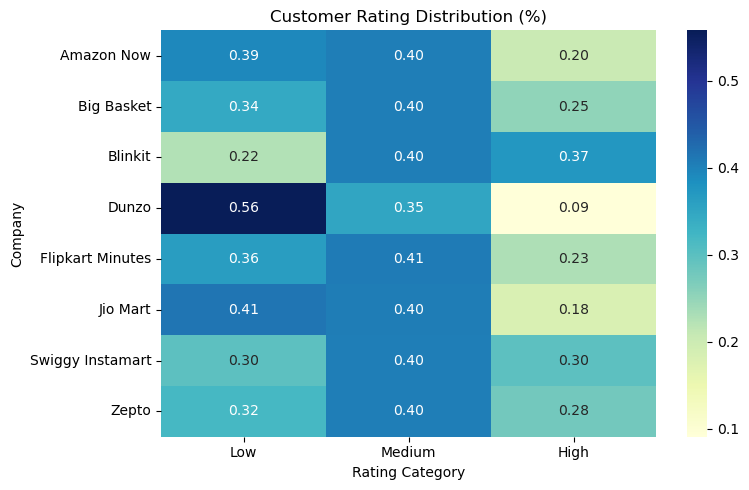

In [51]:
pivot = pd.pivot_table(
    df,
    index="Company",
    columns="Rating_Category",
    aggfunc="size",
    fill_value=0,
    observed=False
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(8,5))
sns.heatmap(pivot_pct, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("Customer Rating Distribution (%)")
plt.xlabel("Rating Category")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

### **Does delivery time affects the Delivery Partner Ratings?**

In [55]:
Delivery_Mean = df.groupby("Delivery_Time_Min")["Delivery_Partner_Rating"].mean()

In [53]:
df["Delivery_Time_Min"].corr(df["Delivery_Partner_Rating"])

np.float64(-0.0016061879971777549)

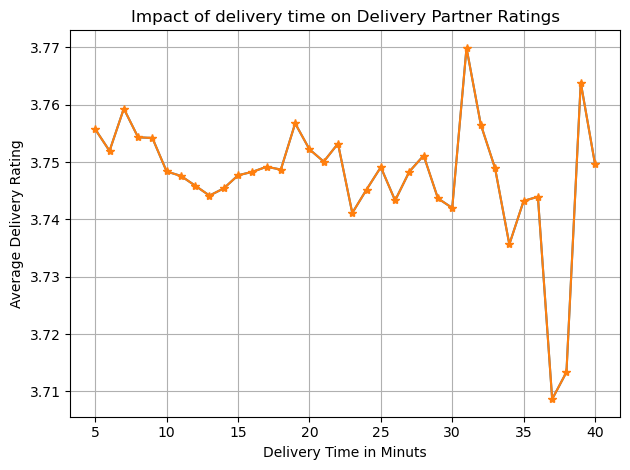

In [65]:
Delivery_Mean.plot()
Delivery_Mean.plot(marker="*")
plt.grid(True)
plt.xlabel("Delivery Time in Minuts")
plt.ylabel("Average Delivery Rating")
plt.title("Impact of delivery time on Delivery Partner Ratings")
plt.tight_layout()
plt.show()

### **What is the post popular category on each platform?**

In [83]:
df.groupby("Company")["Product_Category"].value_counts().groupby("Company").idxmax()


Company
Amazon Now            (Amazon Now, Personal Care)
Big Basket            (Big Basket, Personal Care)
Blinkit                      (Blinkit, Groceries)
Dunzo                          (Dunzo, Groceries)
Flipkart Minutes    (Flipkart Minutes, Groceries)
Jio Mart                        (Jio Mart, Dairy)
Swiggy Instamart        (Swiggy Instamart, Dairy)
Zepto                              (Zepto, Dairy)
Name: count, dtype: object

In [79]:
result = (
    df.groupby("Company")["Product_Category"]
      .value_counts()
      .groupby(level=0)
      .idxmax()
      .apply(lambda x: x[1])
)
result

Company
Amazon Now          Personal Care
Big Basket          Personal Care
Blinkit                 Groceries
Dunzo                   Groceries
Flipkart Minutes        Groceries
Jio Mart                    Dairy
Swiggy Instamart            Dairy
Zepto                       Dairy
Name: count, dtype: object

In [82]:
df.groupby("Company")["Product_Category"]\
  .agg(lambda x: x.value_counts().idxmax())

Company
Amazon Now          Personal Care
Big Basket          Personal Care
Blinkit                 Groceries
Dunzo                   Groceries
Flipkart Minutes        Groceries
Jio Mart                    Dairy
Swiggy Instamart            Dairy
Zepto                       Dairy
Name: Product_Category, dtype: object

### **What is the post popular category on Swiggy instamart for the people of age between 30-40 in Mumbai?**

In [85]:
df_pc = df[
            (df["Company"]=="Swiggy Instamart") &
            ((df["Customer_Age"]>=30) & (df["Customer_Age"]<40)) &
            (df["City"]=="Mumbai")
]
df_pc

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Rating_Category,Delivery_Time_Bucket
536,1000537,Swiggy Instamart,Mumbai,38,1157,14,5.70,18.00,Beverages,Cash on Delivery,3.50,1,4.30,Medium,Fast
909,1000910,Swiggy Instamart,Mumbai,32,926,20,14.20,3.00,Dairy,UPI,2.40,0,4.60,Low,Fast
1203,1001204,Swiggy Instamart,Mumbai,37,234,19,7.60,6.00,Dairy,Debit Card,5.00,0,3.50,High,Fast
2918,1002919,Swiggy Instamart,Mumbai,31,423,15,4.00,10.00,Dairy,Cash on Delivery,2.30,0,2.70,Low,Fast
4251,1004252,Swiggy Instamart,Mumbai,36,50,15,2.20,12.00,Dairy,Credit Card,3.10,0,3.00,Medium,Fast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997610,1997611,Swiggy Instamart,Mumbai,37,448,19,14.00,17.00,Fruits & Vegetables,Cash on Delivery,5.00,0,4.70,High,Fast
999242,1999243,Swiggy Instamart,Mumbai,32,747,13,2.40,12.00,Household,UPI,5.00,1,4.90,High,Fast
999258,1999259,Swiggy Instamart,Mumbai,35,50,18,7.60,4.00,Personal Care,Debit Card,5.00,0,4.80,High,Fast
999680,1999681,Swiggy Instamart,Mumbai,39,375,19,8.70,6.00,Household,Wallet,1.80,0,4.30,Low,Fast


In [87]:
df_pc["Product_Category"].value_counts().sort_values(ascending=False)

Product_Category
Dairy                  368
Fruits & Vegetables    343
Groceries              341
Household              340
Snacks                 329
Personal Care          305
Beverages              299
Name: count, dtype: int64

In [ ]:
### **Which city should these companies expand into based on perfromance?**

In [93]:
city_perf = df.groupby(['Company', 'City']).agg(
    Total_Orders=('Order_ID', 'count'),
    Avg_Rating=("Customer_Rating", 'mean'),
    Avg_Delivery_Time=('Delivery_Time_Min', 'mean'),
    Total_Revenue=('Order_Value', 'sum')
).reset_index()
city_perf

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
0,Amazon Now,Amritsar,9929,2.89,18.17,5469439
1,Amazon Now,Bengluru,9905,3.36,19.18,5629936
2,Amazon Now,Chennai,9847,2.90,18.14,5363559
3,Amazon Now,Delhi,9918,2.99,8.29,5891026
4,Amazon Now,Gurgaon,9797,2.92,18.17,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9678,3.12,13.15,4621428
92,Zepto,Kolkata,9825,3.18,8.30,5776955
93,Zepto,Mumbai,9861,3.38,10.15,6046485
94,Zepto,Noida,10070,3.21,8.30,7070769


In [94]:
best_cities = city_perf[
    (city_perf['Avg_Rating'] >= 3.5) &
    (city_perf['Avg_Delivery_Time'] <= 15) &
    (city_perf['Total_Orders'] > city_perf['Total_Orders'].median())
]
best_cities

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
24,Blinkit,Amritsar,9932,3.57,14.20,6006361
26,Blinkit,Chennai,9876,3.56,14.14,5921870
28,Blinkit,Gurgaon,10078,3.55,14.20,7374774
32,Blinkit,Kolkata,10004,3.54,14.14,6003384
35,Blinkit,Pune,9908,3.55,14.16,5930415
85,Zepto,Bengluru,9971,3.61,9.20,6041668


In [96]:
best_cities[["Company","City"]]

,Company,City
24,Blinkit,Amritsar
26,Blinkit,Chennai
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
35,Blinkit,Pune
85,Zepto,Bengluru


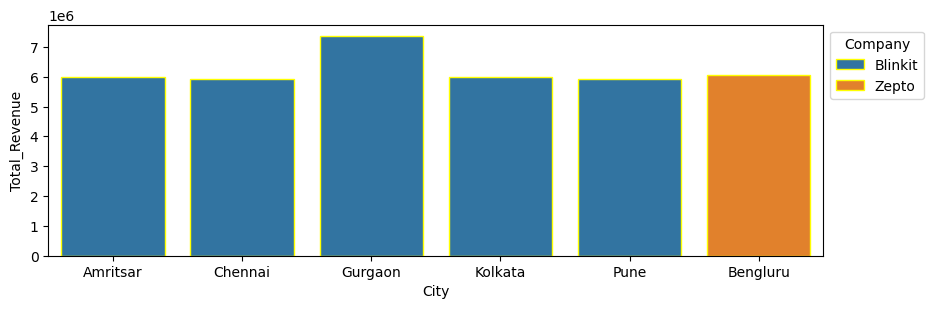

In [101]:
plt.figure(figsize=(10,3))
sns.barplot(data=best_cities, x="City", y="Total_Revenue", hue="Company", edgecolor="yellow")
plt.legend(title="Company", bbox_to_anchor=(1,1))
plt.show()

### **Are Discounts increasing order volume or Reducing Revenue?**

In [116]:
dis_order_value = df.groupby("Discount_Applied")["Order_Value"].mean()
dis_order_value

Discount_Applied
0   476.42
1   712.19
Name: Order_Value, dtype: float64

In [108]:
dis_items_count = df.groupby("Discount_Applied")["Items_Count"].sum()
dis_items_count

Discount_Applied
0   5,854,258.00
1   3,920,185.00
Name: Items_Count, dtype: float64

In [113]:
x = df["Discount_Applied"].unique()
x

array([1, 0])

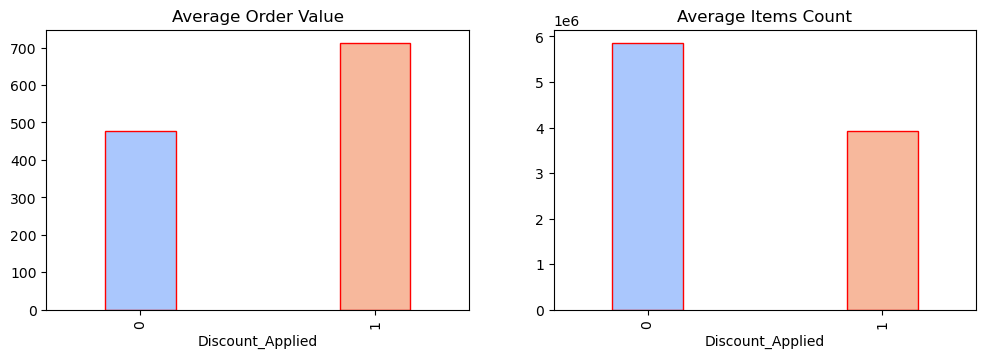

In [121]:
plt.figure(figsize=(12,8))
colors = sns.color_palette("coolwarm", len(x))

plt.subplot(2,2,1)
dis_order_value.plot(kind="bar", width=0.3, edgecolor="red", color=colors)
plt.title("Average Order Value")

plt.subplot(2,2,2)
dis_items_count.plot(kind="bar", width=0.3, edgecolor="red", color=colors)
plt.title("Average Items Count")

plt.show()

### **Which Company has the best operational Efficiency (Delivery Time vs Order Volume)?**

In [125]:
company_eff = df.groupby("Company").agg(
    Total_Orders = ("Order_ID", "count"),
    Avg_Delivery_Time = ("Delivery_Time_Min", "mean")
).reset_index()

company_eff

,Company,Total_Orders,Avg_Delivery_Time
0,Amazon Now,118083,18.98
1,Big Basket,118047,18.03
2,Blinkit,118887,15.12
3,Dunzo,118463,14.18
4,Flipkart Minutes,118965,17.05
5,Jio Mart,118267,23.01
6,Swiggy Instamart,118475,16.07
7,Zepto,118565,9.64


In [128]:
scaler = MinMaxScaler()
company_eff[["Total_Orders_Scaled", "Avg_Delivery_Time_Scaled"]] = scaler.fit_transform(
    company_eff[["Total_Orders", "Avg_Delivery_Time"]]
)

In [129]:
company_eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled
0,Amazon Now,118083,18.98,0.04,0.70
1,Big Basket,118047,18.03,0.00,0.63
2,Blinkit,118887,15.12,0.92,0.41
3,Dunzo,118463,14.18,0.45,0.34
4,Flipkart Minutes,118965,17.05,1.00,0.55
5,Jio Mart,118267,23.01,0.24,1.00
6,Swiggy Instamart,118475,16.07,0.47,0.48
7,Zepto,118565,9.64,0.56,0.00


In [131]:
company_eff["Efficiency_Score"] = company_eff["Total_Orders_Scaled"] - company_eff["Avg_Delivery_Time_Scaled"]

In [134]:
eff = company_eff.sort_values(by ="Efficiency_Score", ascending=False )
eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
7,Zepto,118565,9.64,0.56,0.00,0.56
2,Blinkit,118887,15.12,0.92,0.41,0.51
4,Flipkart Minutes,118965,17.05,1.00,0.55,0.45
3,Dunzo,118463,14.18,0.45,0.34,0.11
6,Swiggy Instamart,118475,16.07,0.47,0.48,-0.01
1,Big Basket,118047,18.03,0.00,0.63,-0.63
0,Amazon Now,118083,18.98,0.04,0.70,-0.66
5,Jio Mart,118267,23.01,0.24,1.00,-0.76


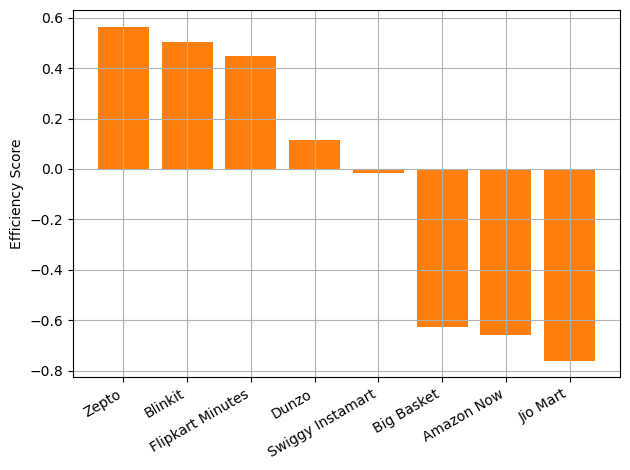

In [140]:
plt.bar(eff["Company"], eff["Efficiency_Score"])
plt.grid(True)
plt.ylabel("Efficiency Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

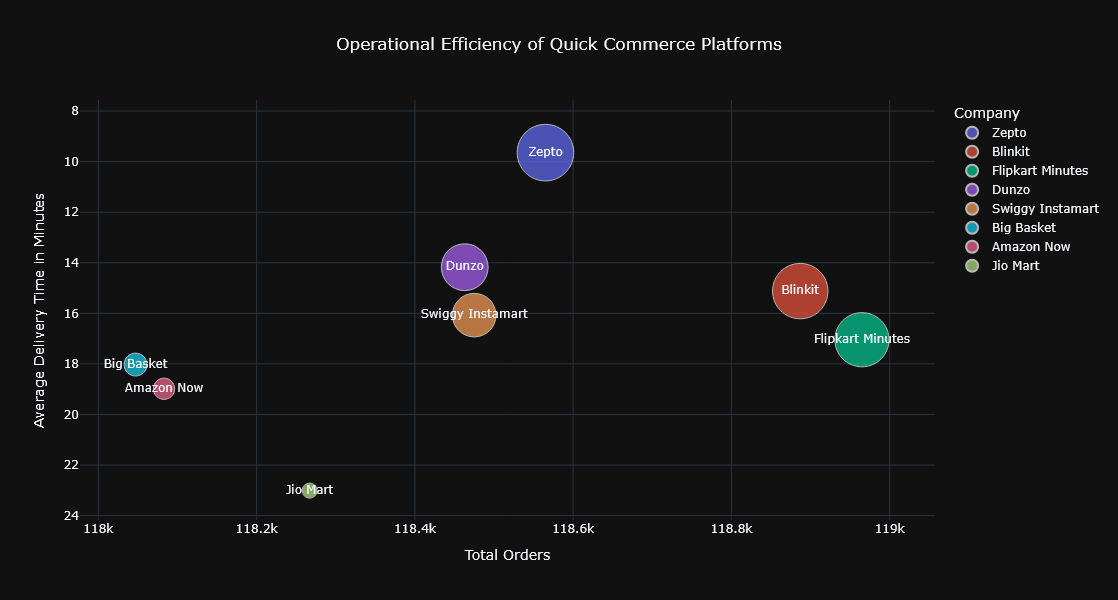

In [152]:
# Bubble size
min_eff = eff["Efficiency_Score"].min()
eff["Bubble_Size"]= eff["Efficiency_Score"] - min_eff+0.1


fig = px.scatter(eff, x="Total_Orders", y="Avg_Delivery_Time", size="Bubble_Size", color="Company", text="Company",
                 title="Operational Efficiency of Quick Commerce Platforms", hover_data = {"Total_Orders":True, "Avg_Delivery_Time":":.2f",
                 "Efficiency_Score":":.3f" }, size_max=40)   


fig.update_traces(textposition="middle center")
fig.update_traces(marker=dict(line=dict(width=1, color='white')))


fig.update_layout(
    xaxis_title="Total Orders",
    yaxis_title ="Average Delivery Time in Minutes",
    title_x=0.5,
    template="plotly_dark",
    height=600
)

fig.update_yaxes(autorange="reversed")

fig.show()

### **Mini Dashboard**

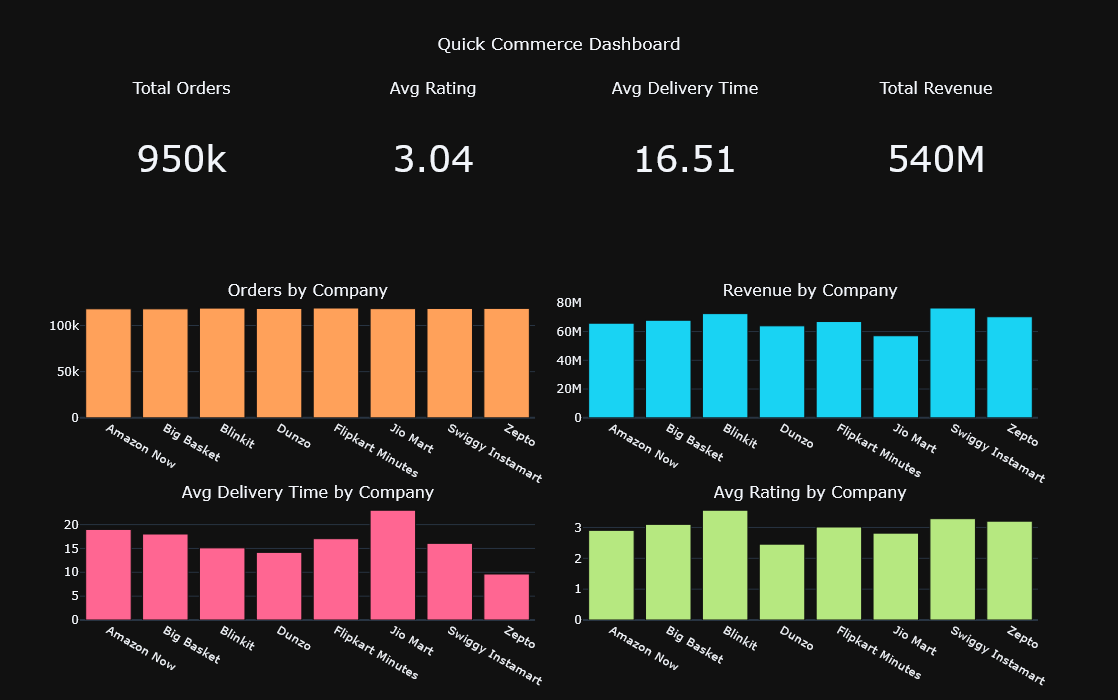

In [186]:
company_metrics = df.groupby('Company').agg(
    Orders=('Order_ID', 'count'),
    Revenue=('Order_Value', 'sum'),
    Avg_Delivery_Time=('Delivery_Time_Min', 'mean'),
    Avg_Rating=('Customer_Rating', 'mean')
).reset_index()

# KPIs
total_orders = company_metrics["Orders"].sum()
total_revenue = company_metrics["Revenue"].sum()
avg_delivery_time = company_metrics["Avg_Delivery_Time"].mean()
avg_rating = company_metrics["Avg_Rating"].mean()


fig = make_subplots(
    rows=3, cols=4,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "bar", "colspan": 2}, None, {"type": "bar", "colspan": 2}, None],
        [{"type": "bar", "colspan": 2}, None, {"type": "bar", "colspan": 2}, None]
    ],
    subplot_titles=(
        "Total Orders", "Avg Rating", "Avg Delivery Time", "Total Revenue",
        "Orders by Company", "Revenue by Company",
        "Avg Delivery Time by Company", "Avg Rating by Company"
    )
)


# KPI CARDS (Top Row)
fig.add_trace(go.Indicator(
    mode="number",
    value=total_orders,
    number={"valueformat": ".2s", "font": {"size": 36}},
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=avg_rating,
    number={"valueformat": ".2f", "font": {"size": 36}},
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=avg_delivery_time,
    number={"valueformat": ".2f", "font": {"size": 36}},
), row=1, col=3)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    number={"valueformat": ".2s", "font": {"size": 36}},
), row=1, col=4)


# BAR CHARTS (Bottom Row)
# Orders
fig.add_trace(go.Bar(
    x=company_metrics["Company"],
    y=company_metrics["Orders"],
    name="Orders",
    marker=dict(line=dict(width=1))
), row=2, col=1)

# Revenue
fig.add_trace(go.Bar(
    x=company_metrics["Company"],
    y=company_metrics["Revenue"],
    name="Revenue",
    marker=dict(line=dict(width=1))
), row=2, col=3)

# Average delivery time
fig.add_trace(go.Bar(
    x=company_metrics["Company"],
    y=company_metrics["Avg_Delivery_Time"],
    name="Average Delivery Time",
    marker=dict(line=dict(width=1))
), row=3, col=1)

# Average Customer rating by Company
fig.add_trace(go.Bar(
    x=company_metrics["Company"],
    y=company_metrics["Avg_Rating"],
    name="Average Customer Rating",
    marker=dict(line=dict(width=1))
), row=3, col=3)


# Layout 
fig.update_layout(
    height=700,
    title="Quick Commerce Dashboard",
    title_x=0.5,
    template="plotly_dark",
    showlegend=False
)


fig.update_xaxes(tickangle=30)

fig.show()